# Avaliação do Modelo e Insights de Negócio

## Objetivo

Avaliar o desempenho do modelo de previsão desenvolvido nas etapas anteriores e transformar seus resultados em insights relevantes para o negócio.

Esta etapa concentra-se na avaliação das métricas do modelo, análise dos erros, comportamento das previsões e interpretação dos resultados gerados para o horizonte de 28 dias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Carregamento dos dados de validação
validation_modeling = pd.read_parquet(
    "../data/processed/validation_modeling.parquet"
)

# Carregamento das previsões de 28 dias
forecast_28_days = pd.read_parquet(
    "../data/processed/forecast_28_days.parquet"
)

print("Dimensão da validação:", validation_modeling.shape)
print("Dimensão das previsões:", forecast_28_days.shape)

Dimensão da validação: (85372, 26)
Dimensão das previsões: (85372, 5)


In [2]:
validation_modeling.head()

,item_id,store_id,d,lag_1,lag_7,lag_14,lag_28,wday,weekday,month,...,event_name_1,event_type_1,event_name_2,event_type_2,day_num,_day_num,rolling_mean_7,rolling_mean_14,rolling_mean_28,sales
0,FOODS_1_001,CA_1,d_1886,0.0,0.0,3.0,1.0,3,Monday,3,...,NoEvent,NoEvent,NoEvent,NoEvent,1886,1886,0.857143,1.142857,0.857143,2
1,FOODS_1_001,CA_1,d_1887,2.0,2.0,0.0,0.0,4,Tuesday,3,...,NoEvent,NoEvent,NoEvent,NoEvent,1887,1887,1.142857,1.071429,0.892857,1
2,FOODS_1_001,CA_1,d_1888,1.0,2.0,0.0,1.0,5,Wednesday,3,...,NoEvent,NoEvent,NoEvent,NoEvent,1888,1888,1.000000,1.142857,0.928571,1
3,FOODS_1_001,CA_1,d_1889,1.0,0.0,2.0,0.0,6,Thursday,3,...,NoEvent,NoEvent,NoEvent,NoEvent,1889,1889,0.857143,1.214286,0.928571,0
4,FOODS_1_001,CA_1,d_1890,0.0,1.0,1.0,0.0,7,Friday,4,...,NoEvent,NoEvent,NoEvent,NoEvent,1890,1890,0.857143,1.071429,0.928571,4


## 1. Avaliação do Modelo

A avaliação será realizada sobre o conjunto de validação definido na etapa de preparação dos dados.

Serão utilizadas as métricas MAE (Mean Absolute Error) e RMSE (Root Mean Squared Error), permitindo avaliar tanto o erro médio absoluto das previsões quanto a influência de erros maiores.

In [3]:
import lightgbm as lgb

# Carregamento do modelo final
model = lgb.Booster(
    model_file="../models/lightgbm_final.txt"
)

print("Modelo carregado com sucesso.")
print("Número de iterações:", model.best_iteration)

Modelo carregado com sucesso.
Número de iterações: -1


In [4]:
# Features utilizadas pelo modelo
features = [
    "item_id",
    "store_id",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "wday",
    "weekday",
    "month",
    "year",
    "week_of_year",
    "snap_CA",
    "snap_TX",
    "snap_WI",
    "snap",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
    "day_num",
    "_day_num",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

X_validation = validation_modeling[features]
y_validation = validation_modeling["sales"]

print("Features utilizadas:", len(features))
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

Features utilizadas: 24
X_validation: (85372, 24)
y_validation: (85372,)


In [5]:
# Geração das previsões para o conjunto de validação
y_pred = model.predict(X_validation)

# Cálculo das métricas
mae = mean_absolute_error(y_validation, y_pred)
rmse = np.sqrt(mean_squared_error(y_validation, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 1.0350
RMSE: 1.9974


## 2. Resultados da Avaliação

O modelo apresentou os seguintes resultados no conjunto de validação:

- **MAE:** 1,0350
- **RMSE:** 1,9974

O MAE representa o erro absoluto médio entre a demanda observada e a demanda prevista. O RMSE atribui maior peso aos erros mais elevados, permitindo identificar a influência de desvios maiores no desempenho do modelo.

Os resultados obtidos nesta etapa são consistentes com as métricas registradas durante o desenvolvimento do modelo, confirmando a reprodução do desempenho do modelo final salvo.

In [6]:
# Cálculo dos erros de previsão
errors = y_validation - y_pred

print("Erro médio:", errors.mean())
print("Erro mínimo:", errors.min())
print("Erro máximo:", errors.max())
print("Mediana do erro:", errors.median())

Erro médio: -0.013327247029209555
Erro mínimo: -67.02152102468189
Erro máximo: 71.07059038313538
Mediana do erro: -0.19085533432923224


## 3. Análise dos Erros

O erro médio de aproximadamente -0,013 indica que, de forma agregada, não existe um viés relevante entre os valores previstos e observados.

A mediana do erro foi de aproximadamente -0,191, indicando uma leve tendência de subestimação em parte das previsões.

Os valores mínimo e máximo apresentam desvios significativamente maiores, mostrando que existem algumas observações com erros elevados. Esses casos devem ser analisados separadamente para verificar se estão associados a séries com demanda mais elevada ou a comportamentos pontuais da demanda.

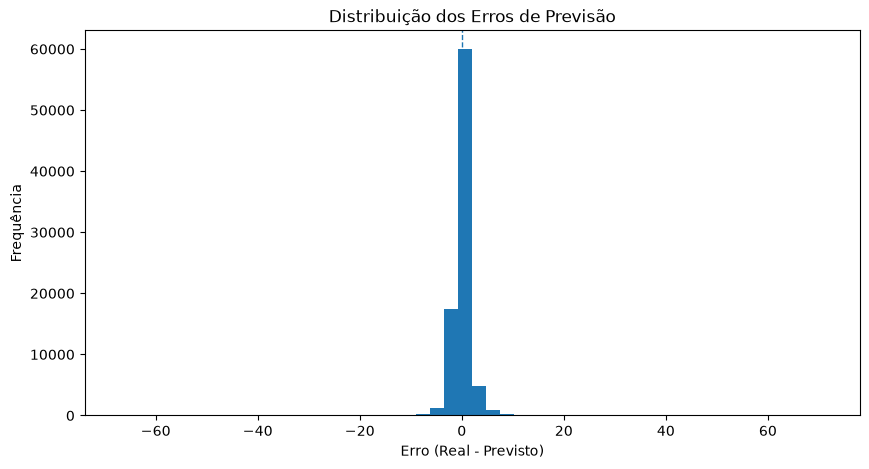

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(errors, bins=50)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Distribuição dos Erros de Previsão")
plt.xlabel("Erro (Real - Previsto)")
plt.ylabel("Frequência")

plt.show()

## Interpretação da Distribuição dos Erros

A distribuição dos erros apresenta forte concentração próxima de zero, indicando que a maior parte das previsões apresenta desvios relativamente pequenos em relação aos valores observados.

Também são observados poucos casos com erros significativamente maiores, representados pelas caudas da distribuição. Esses casos contribuem para o aumento do RMSE em relação ao MAE e indicam a existência de observações pontuais em que o modelo apresenta maior dificuldade de previsão.

De forma geral, a distribuição indica baixo viés agregado e concentração dos erros em torno de zero, embora existam casos específicos que merecem investigação.

In [8]:
# Identificação das previsões com maiores erros absolutos
error_analysis = validation_modeling[
    ["item_id", "store_id", "d", "sales"]
].copy()

error_analysis["prediction"] = y_pred
error_analysis["error"] = error_analysis["sales"] - error_analysis["prediction"]
error_analysis["absolute_error"] = error_analysis["error"].abs()

top_errors = error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

top_errors

,item_id,store_id,d,sales,prediction,error,absolute_error
68803,HOUSEHOLD_1_465,CA_1,d_1893,82,10.929410,71.070590,71.070590
20509,FOODS_3_120,CA_1,d_1899,0,67.021521,-67.021521,67.021521
31083,FOODS_3_498,CA_1,d_1889,64,1.087598,62.912402,62.912402
25397,FOODS_3_295,CA_1,d_1887,78,20.453427,57.546573,57.546573
31165,FOODS_3_501,CA_1,d_1887,66,16.489564,49.510436,49.510436
20502,FOODS_3_120,CA_1,d_1892,126,77.254890,48.745110,48.745110
47807,HOBBIES_1_278,CA_1,d_1897,48,0.844300,47.155700,47.155700
25045,FOODS_3_282,CA_1,d_1899,1,45.276097,-44.276097,44.276097
47334,HOBBIES_1_261,CA_1,d_1900,50,6.198586,43.801414,43.801414
20501,FOODS_3_120,CA_1,d_1891,109,65.377262,43.622738,43.622738


## Análise dos Maiores Erros

A análise dos maiores erros absolutos mostra que os desvios mais elevados estão concentrados em algumas séries específicas e determinados dias da janela de validação.

Foram observados tanto casos de subestimação, nos quais a demanda realizada foi significativamente superior à previsão, quanto casos de superestimação, nos quais o modelo previu uma demanda muito acima do valor observado.

O item `FOODS_3_120` aparece entre os maiores erros em diferentes dias da validação, indicando que algumas séries podem apresentar comportamentos de demanda mais difíceis de capturar pelo modelo.

A análise dos erros permite identificar essas situações para investigação, sem atribuir uma causa específica aos desvios quando ela não pode ser determinada diretamente pelos dados disponíveis.

In [9]:
error_by_item = (
    error_analysis
    .groupby(["item_id", "store_id"])
    .agg(
        MAE=("absolute_error", "mean"),
        erro_maximo=("absolute_error", "max"),
        observacoes=("absolute_error", "count")
    )
    .sort_values("MAE", ascending=False)
    .head(10)
)

error_by_item

,,MAE,erro_maximo,observacoes
item_id,store_id,,,
FOODS_3_120,CA_1,20.074945,67.021521,28
FOODS_3_090,CA_1,12.594916,26.892823,28
FOODS_3_501,CA_1,10.678504,49.510436,28
FOODS_3_295,CA_1,9.206225,57.546573,28
HOBBIES_1_048,CA_1,9.002946,41.592522,28
HOBBIES_1_268,CA_1,8.570932,32.862470,28
HOBBIES_1_189,CA_1,7.749731,26.186548,28
HOBBIES_1_371,CA_1,7.639490,20.165409,28
HOUSEHOLD_1_465,CA_1,7.595192,71.070590,28


## Interpretação por Série

A análise agregada por item e loja mostra que o desempenho do modelo varia entre as diferentes séries de demanda.

O item `FOODS_3_120` apresentou o maior MAE entre as séries analisadas, com valor de 20,07, além de um erro máximo de 67,02. Outros itens também apresentaram erros médios superiores aos observados no conjunto geral.

Esse resultado evidencia que o desempenho agregado do modelo não representa igualmente todas as séries. Algumas categorias e produtos apresentam maior dificuldade de previsão, o que pode justificar análises específicas em aplicações reais de planejamento de estoque e reposição.

## 4. Insights de Negócio

Os resultados da avaliação permitem destacar alguns pontos relevantes para a utilização das previsões:

- O modelo apresenta baixo viés agregado, com erro médio próximo de zero.
- A maior parte dos erros está concentrada próxima de zero.
- Existem séries específicas com erros significativamente maiores que o comportamento médio.
- A previsão de demanda pode apoiar decisões de planejamento de estoque e reposição para o horizonte de 28 dias.
- Séries com maior erro devem receber acompanhamento adicional antes de decisões automatizadas de estoque.

In [10]:
top_forecast_items = (
    forecast_28_days
    .groupby(["item_id", "store_id"])["prediction"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_forecast_items

,item_id,store_id,prediction
0,FOODS_3_090,CA_1,1506.733748
1,FOODS_3_120,CA_1,1269.951857
2,FOODS_3_586,CA_1,1116.011597
3,FOODS_3_252,CA_1,1022.035787
4,FOODS_3_064,CA_1,718.491130
5,FOODS_3_587,CA_1,656.003791
6,FOODS_3_282,CA_1,648.050549
7,FOODS_3_681,CA_1,572.844368
8,FOODS_3_714,CA_1,564.575716
9,FOODS_2_197,CA_1,563.284540


## Demanda Prevista por Série

A previsão para os próximos 28 dias apresenta concentração de demanda em algumas séries específicas.

O item `FOODS_3_090` apresenta o maior volume previsto, com aproximadamente 1.507 unidades no horizonte analisado, seguido por `FOODS_3_120`, com aproximadamente 1.270 unidades.

O item `FOODS_3_120` merece atenção adicional por combinar um volume previsto elevado com um dos maiores erros observados na validação. Em um cenário de aplicação real, séries com esse perfil poderiam ser acompanhadas com maior atenção no planejamento de estoque e reposição.

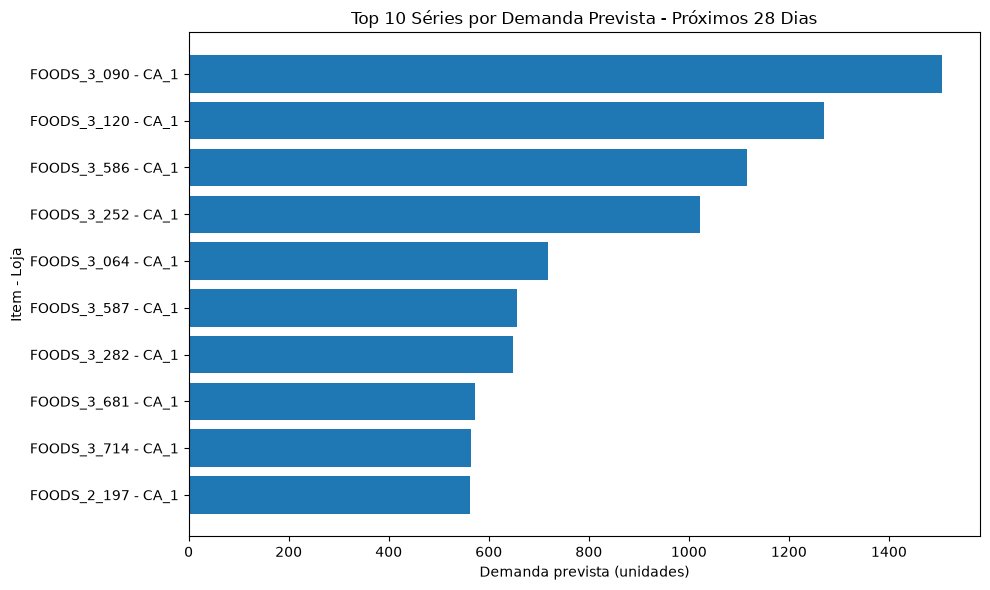

In [11]:
plt.figure(figsize=(10, 6))

labels = (
    top_forecast_items["item_id"].astype(str)
    + " - "
    + top_forecast_items["store_id"].astype(str)
)

plt.barh(labels, top_forecast_items["prediction"])

plt.gca().invert_yaxis()

plt.title("Top 10 Séries por Demanda Prevista - Próximos 28 Dias")
plt.xlabel("Demanda prevista (unidades)")
plt.ylabel("Item - Loja")

plt.tight_layout()
plt.show()

## 5. Conclusão

A avaliação realizada confirmou o desempenho do modelo final sobre o conjunto de validação, com MAE de 1,0350 e RMSE de 1,9974.

A distribuição dos erros apresentou forte concentração próxima de zero, indicando baixo viés agregado. Entretanto, a análise por série mostrou que o desempenho não é uniforme, com determinados itens apresentando erros significativamente superiores à média.

Para o horizonte de 28 dias, a previsão também permitiu identificar as séries com maior demanda esperada, fornecendo uma visão direcionada para planejamento de estoque e reposição.

Os resultados demonstram como modelos de previsão de demanda podem transformar dados históricos em informações de apoio à tomada de decisão, mantendo a necessidade de acompanhamento das séries que apresentam maior incerteza ou erro de previsão.

## Resumo Executivo

**Desempenho do modelo**
- MAE: **1,0350**
- RMSE: **1,9974**
- Registros avaliados: **85.372**

**Previsão**
- Horizonte: **28 dias**
- Séries previstas: **3.049**
- Período: **25/04/2016 a 22/05/2016**

**Principais achados**
- Erros concentrados próximos de zero.
- Baixo viés agregado.
- Algumas séries apresentam maior dificuldade de previsão.
- `FOODS_3_090` apresenta a maior demanda prevista no horizonte.
- `FOODS_3_120` combina alta demanda prevista com maior erro médio entre as séries analisadas, merecendo acompanhamento adicional.